In [2]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class Cric_State(TypedDict):

    runs : int
    balls : int
    fours : int
    sixes : int

    strike_rate : float
    boundary_per : float
    balls_per_bound : float
    summary : str

In [11]:
def strike_rate(state: Cric_State)-> Cric_State:

    runs_scored = state["runs"]
    balls_faced = state["balls"]

    sr = (runs_scored / balls_faced) * 100

    state["strike_rate"] = sr

    return {"strike_rate" : sr}

In [12]:
def boundary_per(state : Cric_State) -> Cric_State:

    boundary_runs = (state["fours"] * 4) + (state["sixes"] * 6)
    total_runs_scored = state["runs"]

    boundary_percentage = (boundary_runs / total_runs_scored) * 100

    state["boundary_per"] = boundary_percentage

    return {"boundary_per" : boundary_percentage}


In [13]:
def balls_per_bound(state : Cric_State) -> Cric_State:

    boundaries = (state["fours"]) + (state["sixes"])
    balls_faced = state["balls"]
    
    bpb = (balls_faced / boundaries)

    state["balls_per_bound"] = bpb

    return {"balls_per_bound" : bpb}

In [7]:
def summary(state: Cric_State)-> Cric_State:

    summary = f"""
Strike_rate - {state["strike_rate"]} \n
Boundary_percentage - {state["boundary_per"]} \n
Balls_per_boundry - {state["balls_per_bound"]} 
"""
    state["summary"] = summary

    return state

In [14]:
graph = StateGraph(Cric_State)

# nodes
graph.add_node("strike_rate", strike_rate)
graph.add_node("boundary_per", boundary_per)
graph.add_node("balls_per_bound", balls_per_bound)
graph.add_node("summary", summary)

# edges
graph.add_edge(START, "strike_rate")
graph.add_edge(START, "boundary_per")
graph.add_edge(START, "balls_per_bound")

graph.add_edge("strike_rate", "summary")
graph.add_edge("boundary_per", "summary")
graph.add_edge("balls_per_bound", "summary")

graph.add_edge("summary", END)

workflow = graph.compile()


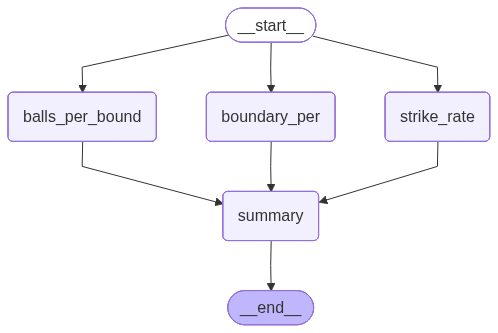

In [15]:
workflow

In [16]:
initial_state = {
    "runs" : 100,
    "balls" : 50,
    "fours" : 6,
    "sixes" : 4
}

final_state = workflow.invoke(initial_state)

In [17]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'strike_rate': 200.0,
 'boundary_per': 48.0,
 'balls_per_bound': 5.0,
 'summary': '\nStrike_rate - 200.0 \n\nBoundary_percentage - 48.0 \n\nBalls_per_boundry - 5.0 \n'}

In [18]:
print(final_state["summary"])


Strike_rate - 200.0 

Boundary_percentage - 48.0 

Balls_per_boundry - 5.0 

